# Hospital Distance Metric by County in Wisconsin
**Team Number:** Group 27  
**Members:** Ashley Swenson, Alex Wong, Avanti Kekane, Tanvi Raman

## Overview
This notebook contains the data cleaning, methodology, and calculations to create a metric to quatify the distance to the nearest hospital by county.



In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas     
import numpy as np
from shapely.geometry import Point
import requests
from sklearn.neighbors import BallTree

Reading data provided by Wisconsin Department of Health Services that has hospital location cordinates in Wisconisin (last updated in 2024).

In [3]:
#RETRIVING HOSPITAL LOCATION DATA
us = geopandas.read_file('cb_2021_us_county_5m.zip')
wisco = us[us['STATE_NAME'] == 'Wisconsin']
hospitals = geopandas.read_file('Wisconsin_Hospitals.zip')

In [4]:
hospitals.head()

,OBJECTID,FACILITY_I,ADDRESS,ADDRESS_2,CITY,STATE,ZIP,ZIP_4,LAT,LON,...,COUNTY_FIP,TYPE_DESC,SUB_TYPE_D,WI_LICENSE,ASPEN_FACI,MEDICARE_I,TYPE_CODE,FACILITY_T,FACILITY_N,geometry
0,1,1987,2323 N Lake Dr,None,Milwaukee,WI,53211,4508.0,43.061537,-87.879873,...,55079,HOSPITAL,SHORT TERM,53.0,HSPLACU113,520051,1,11,ASCENSION COLUMBIA ST MARY'S HOSPITAL MILWAUKEE,POINT (-9782742.713 5321343.101)
1,2,2027,507 S Main St,None,Viroqua,WI,54665,2059.0,43.551547,-90.888045,...,55123,HOSPITAL,CRITICAL ACCESS HOSPITALS,1053.0,HSPLACU130,521348,1,14,VERNON MEMORIAL HOSPITAL,POINT (-10117610.889 5396303.307)
2,3,2293,8901 W Lincoln Ave,None,West Allis,WI,53227,2409.0,43.001140,-88.024220,...,55079,HOSPITAL,SHORT TERM,149.0,HSPLACU136,520139,1,11,AURORA WEST ALLIS MEDICAL CENTER,POINT (-9798811.348 5312145.368)
3,4,2437,3100 Superior Ave,None,Sheboygan,WI,53081,1948.0,43.762764,-87.747466,...,55117,HOSPITAL,SHORT TERM,37.0,HSPLACU120,520044,1,11,ST NICHOLAS HOSPITAL,POINT (-9768003.234 5428802.464)
4,5,2438,611 N Saint Joseph Ave,None,Marshfield,WI,54449,1832.0,44.678031,-90.179048,...,55141,HOSPITAL,SHORT TERM,51.0,HSPLACU102,520037,1,11,MARSHFIELD MEDICAL CENTER,POINT (-10038685.704 5570975.677)


We will utilize the Population Bearu's population centroid data that provides the cordinates of the mean centers of population in Wisconsin counties according to the 2020 Census. This provides a more accurate point of measure to estimate how far the nearest hospital is for a majority of residents within a county. 

In [5]:
# US CENTROID POPULATION BEARU DATASET 2020


url = 'https://www2.census.gov/geo/docs/reference/cenpop2020/county/CenPop2020_Mean_CO55.txt'
population_centroid_df = pd.read_csv(url)

population_centroid_df = population_centroid_df.rename(columns = {"COUNAME": "County"})
population_centroid_df.head()

,STATEFP,COUNTYFP,County,STNAME,POPULATION,LATITUDE,LONGITUDE
0,55,1,Adams,Wisconsin,20654,43.946194,-89.783120
1,55,3,Ashland,Wisconsin,16027,46.475919,-90.785419
2,55,5,Barron,Wisconsin,46711,45.437002,-91.815142
3,55,7,Bayfield,Wisconsin,16220,46.594106,-91.104441
4,55,9,Brown,Wisconsin,268740,44.497155,-88.034145


Testing Claude's suggestion for distance measure

In [6]:
#USING RADIANS TO FIND DISTANCE TO THE NEAREST HOSPITAL (THIS ACCOUTNS FOR COUNTIES THAT HAVE A HOSPITAL NEARBY BUT IN A DIFFERENT COUNTY)
hospital_coords_rad = np.radians(hospitals[['LAT', 'LON']].values)
county_coords_rad = np.radians(population_centroid_df[['LATITUDE', 'LONGITUDE']].values)

tree = BallTree(hospital_coords_rad, metric='haversine')
distances, _ = tree.query(county_coords_rad, k=1) 
population_centroid_df['nearest_hospital_km'] = distances[:, 0]

In [7]:

population_centroid_df.sort_values(by='nearest_hospital_km')


,STATEFP,COUNTYFP,County,STNAME,POPULATION,LATITUDE,LONGITUDE,nearest_hospital_km
49,55,97,Portage,Wisconsin,70377,44.498026,-89.526076,0.000119
29,55,59,Kenosha,Wisconsin,169151,42.572393,-87.924047,0.000150
12,55,25,Dane,Wisconsin,561504,43.075640,-89.395501,0.000204
52,55,103,Richland,Wisconsin,17304,43.350268,-90.390394,0.000223
40,55,79,Milwaukee,Wisconsin,939489,43.031416,-87.959526,0.000279
...,...,...,...,...,...,...,...,...
30,55,61,Kewaunee,Wisconsin,20563,44.527818,-87.591703,0.004441
5,55,11,Buffalo,Wisconsin,13317,44.380158,-91.741440,0.005015
20,55,41,Forest,Wisconsin,9179,45.563411,-88.812092,0.006999
25,55,51,Iron,Wisconsin,6137,46.343183,-90.189954,0.007815


In [10]:
population_centroid_df['fips'] = '55' + population_centroid_df['COUNTYFP'].astype(str).str.zfill(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 432.5 kB/s eta 0:00:0000:0100:02


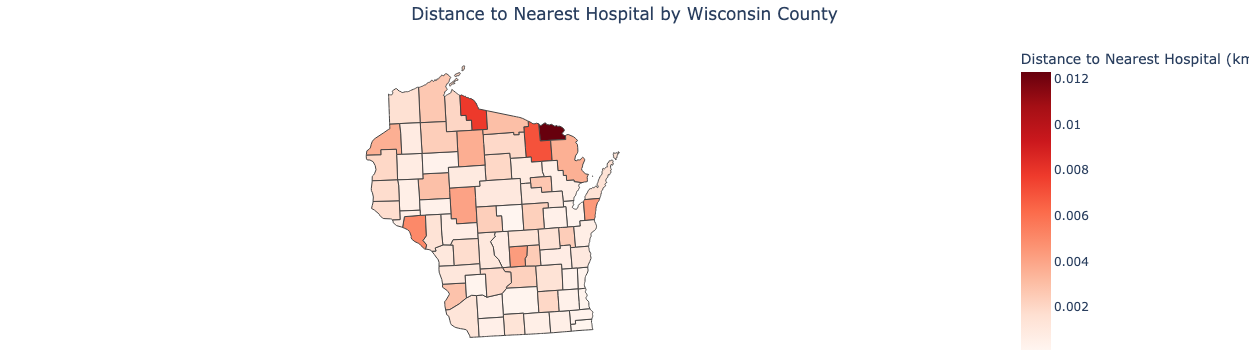

In [12]:
from urllib.request import urlopen
import json
!pip install plotly
import plotly.express as px

# Load GeoJSON
res = urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json')
counties = json.load(res)

# Filter to Wisconsin only
wi_features = [f for f in counties['features'] if f['properties']['STATE'] == '55']
wi_geojson = {'type': 'FeatureCollection', 'features': wi_features}

# Build the figure using your dataframe
fig = px.choropleth(
    population_centroid_df,
    geojson=wi_geojson,
    locations='fips',                        
    color='nearest_hospital_km',
    color_continuous_scale='Reds',
    scope='usa',
    hover_name='County',                     
    hover_data={                            
        'POPULATION': True,
        'nearest_hospital_km': ':.2f'
    },
    labels={'nearest_hospital_km': 'Distance to Nearest Hospital (km)'},
    title='Distance to Nearest Hospital by Wisconsin County'
)

fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(
    plot_bgcolor='white',
    margin={'r': 0, 't': 40, 'l': 0, 'b': 0},
    title={'x': 0.5, 'xanchor': 'center'}
)


fig.write_html('choropleth_hospital_distance.html')
fig.show()